<a href="https://colab.research.google.com/github/alaahaise/Model-IA-Unet-avec-PH2/blob/main/Segmen.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install scikit-image
!pip install -q opencv-python matplotlib

In [ ]:
import os
import zipfile
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"kevorkian96","key":"35db6579a193a77e5f1d3addc15b37e0"}'}

In [ ]:
!pip install -q kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download the dataset directly from Kaggle
!kaggle datasets download -d volodymyrpivoshenko/skin-cancer-lesions-segmentation

# Unzip the dataset
!unzip -q skin-cancer-lesions-segmentation.zip -d skin_cancer


Dataset URL: https://www.kaggle.com/datasets/volodymyrpivoshenko/skin-cancer-lesions-segmentation
License(s): CC-BY-NC-SA-4.0
 99% 2.57G/2.59G [00:44<00:00, 83.6MB/s]
100% 2.59G/2.59G [00:44<00:00, 62.6MB/s]


In [ ]:
import glob

image_dir = 'skin_cancer/data/images'
mask_dir = 'skin_cancer/data/masks'

# Obtenir noms de fichiers (sans extension)
image_names = {os.path.splitext(os.path.basename(p))[0] for p in glob.glob(os.path.join(image_dir, '*.jpg'))}
mask_names  = {os.path.splitext(os.path.basename(p))[0] for p in glob.glob(os.path.join(mask_dir, '*.png'))}

# Trouver l’intersection (images qui ont un masque)
common_names = sorted(image_names & mask_names)

print(f"{len(common_names)} images ont un masque correspondant.")

10015 images ont un masque correspondant.


✔️ Données chargées : (10015, 128, 128, 3) (10015, 128, 128, 1)
Epoch 1/10
501/501 ━━━━━━━━━━━━━━━━━━━━ 39s 52ms/step - accuracy: 0.8324 - loss: 0.3734 - val_accuracy: 0.9170 - val_loss: 0.2119
Epoch 2/10
501/501 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.9194 - loss: 0.2093 - val_accuracy: 0.9242 - val_loss: 0.1970
Epoch 3/10
501/501 ━━━━━━━━━━━━━━━━━━━━ 21s 28ms/step - accuracy: 0.9311 - loss: 0.1790 - val_accuracy: 0.9326 - val_loss: 0.1785
Epoch 4/10
501/501 ━━━━━━━━━━━━━━━━━━━━ 21s 29ms/step - accuracy: 0.9338 - loss: 0.1721 - val_accuracy: 0.9266 - val_loss: 0.1913
Epoch 5/10
501/501 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.9357 - loss: 0.1662 - val_accuracy: 0.9342 - val_loss: 0.1674
Epoch 6/10
501/501 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.9344 - loss: 0.1693 - val_accuracy: 0.9348 - val_loss: 0.1685
Epoch 7/10
501/501 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.9366 - loss: 0.1636 - val_accuracy: 0.9379 - val_loss: 0.1582
Epoch 8/10
501/501 ━━━━━━━

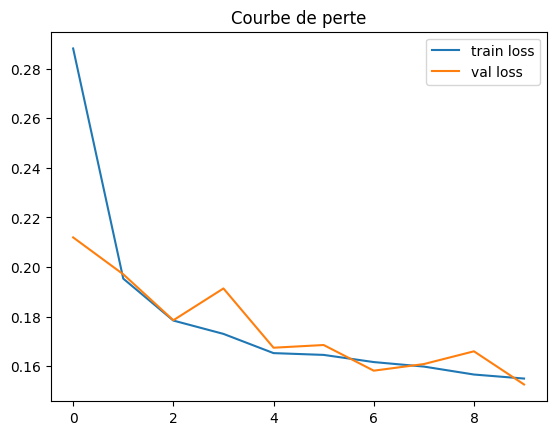

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


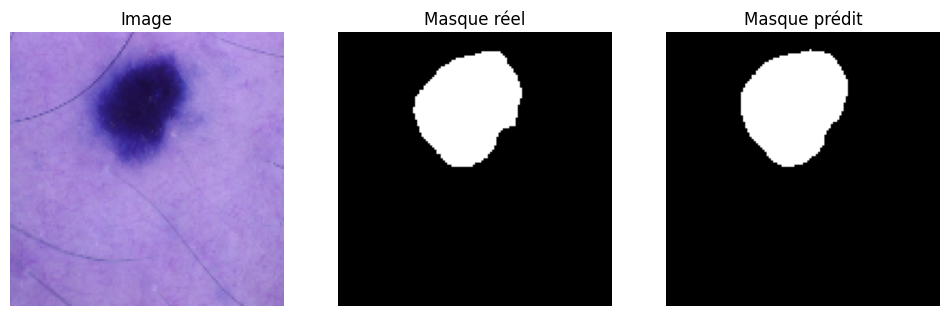

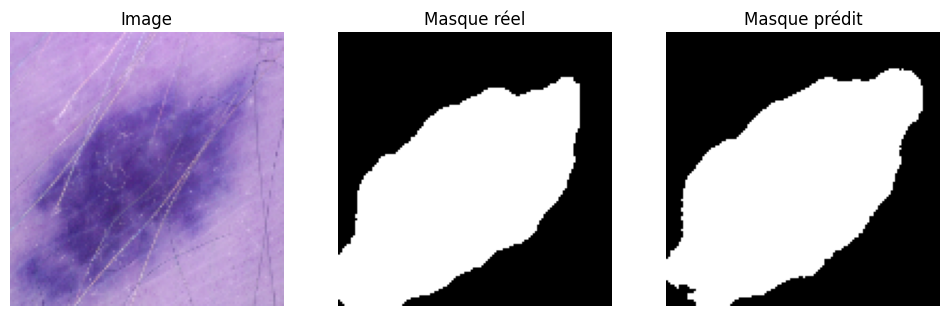

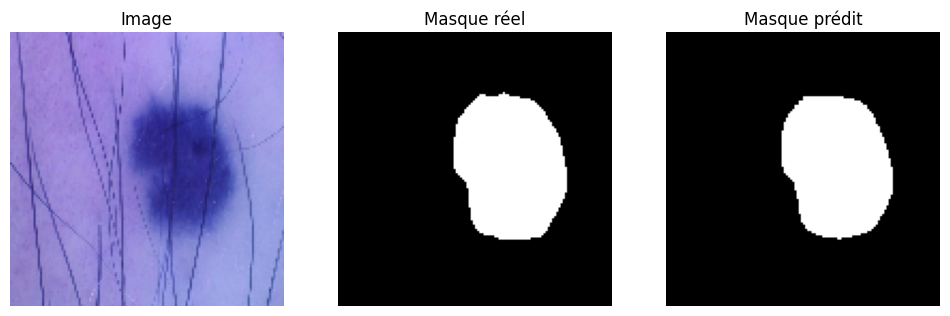

In [ ]:
import glob
import tensorflow as tf
from tensorflow.keras import layers, models

# Répertoire
image_dir = 'skin_cancer/data/images'
mask_dir = 'skin_cancer/data/masks'
IMAGE_SIZE = 128

# Lire noms communs
image_names = {os.path.splitext(os.path.basename(p))[0] for p in glob.glob(os.path.join(image_dir, '*.jpg'))}
mask_names  = {os.path.splitext(os.path.basename(p))[0] for p in glob.glob(os.path.join(mask_dir, '*.png'))}
common_names = sorted(image_names & mask_names)

# Charger images et masques
X, Y = [], []

for name in common_names:
    img_path = os.path.join(image_dir, name + '.jpg')
    mask_path = os.path.join(mask_dir, name + '.png')

    image = cv2.imread(img_path)
    image = cv2.resize(image, (IMAGE_SIZE, IMAGE_SIZE))
    image = image / 255.0

    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    mask = cv2.resize(mask, (IMAGE_SIZE, IMAGE_SIZE))
    mask = (mask > 127).astype(np.float32)

    X.append(image)
    Y.append(np.expand_dims(mask, axis=-1))  # (H, W, 1)

X = np.array(X, dtype=np.float32)
Y = np.array(Y, dtype=np.float32)

print("✔️ Données chargées :", X.shape, Y.shape)

# Split
X_train, X_val, Y_train, Y_val = train_test_split(X, Y, test_size=0.2, random_state=42)

# U-Net simple
def unet_model(input_size=(IMAGE_SIZE, IMAGE_SIZE, 3)):
    inputs = layers.Input(input_size)

    # Encoder
    c1 = layers.Conv2D(16, 3, activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(16, 3, activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D()(c1)

    c2 = layers.Conv2D(32, 3, activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(32, 3, activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D()(c2)

    # Bottleneck
    b = layers.Conv2D(64, 3, activation='relu', padding='same')(p2)
    b = layers.Conv2D(64, 3, activation='relu', padding='same')(b)

    # Decoder
    u1 = layers.UpSampling2D()(b)
    u1 = layers.Concatenate()([u1, c2])
    c3 = layers.Conv2D(32, 3, activation='relu', padding='same')(u1)
    c3 = layers.Conv2D(32, 3, activation='relu', padding='same')(c3)

    u2 = layers.UpSampling2D()(c3)
    u2 = layers.Concatenate()([u2, c1])
    c4 = layers.Conv2D(16, 3, activation='relu', padding='same')(u2)
    c4 = layers.Conv2D(16, 3, activation='relu', padding='same')(c4)

    outputs = layers.Conv2D(1, 1, activation='sigmoid')(c4)

    return models.Model(inputs, outputs)

# Compilation et entraînement
model = unet_model()
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history = model.fit(X_train, Y_train, validation_data=(X_val, Y_val),
                    epochs=10, batch_size=16)

# Afficher les courbes d’apprentissage
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.title("Courbe de perte")
plt.show()

# Prédiction + visualisation
def show_predictions(images, masks, preds, n=3):
    for i in range(n):
        plt.figure(figsize=(12,4))
        plt.subplot(1,3,1)
        plt.imshow(images[i])
        plt.title("Image")
        plt.axis('off')

        plt.subplot(1,3,2)
        plt.imshow(masks[i].squeeze(), cmap='gray')
        plt.title("Masque réel")
        plt.axis('off')

        plt.subplot(1,3,3)
        plt.imshow(preds[i].squeeze() > 0.5, cmap='gray')
        plt.title("Masque prédit")
        plt.axis('off')
        plt.show()

preds = model.predict(X_val[:5])
show_predictions(X_val[:5], Y_val[:5], preds)


In [ ]:
def dice_score(pred, true):
    smooth = 1e-6
    intersection = np.sum(pred * true)
    return (2. * intersection + smooth) / (np.sum(pred) + np.sum(true) + smooth)

val_preds = model.predict(X_val)

def threshold_objective(thresh_vec):
    threshold = thresh_vec[0]
    preds_bin = (val_preds > threshold).astype(np.uint8)

    intersection = np.sum(preds_bin * Y_val)
    union = np.sum(preds_bin) + np.sum(Y_val)
    dice = (2.0 * intersection) / (union + 1e-8)

    return -dice
#bech nfham : This function helps you find the optimal probability threshold for U-Net segmentation outputs, so that your final masks give the highest Dice similarity with ground truth.
#

63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 55ms/step


Iteration 0 | Best Fitness: -0.887877
Iteration 10 | Best Fitness: -0.887879
Iteration 20 | Best Fitness: -0.887879
Iteration 30 | Best Fitness: -0.887879
Iteration 40 | Best Fitness: -0.887879
Iteration 50 | Best Fitness: -0.887879
Iteration 60 | Best Fitness: -0.887879
Iteration 70 | Best Fitness: -0.887879
Iteration 80 | Best Fitness: -0.887879
Iteration 90 | Best Fitness: -0.887879

Best Fitness (Dice) = 0.8878793836
Best Threshold = 0.4611


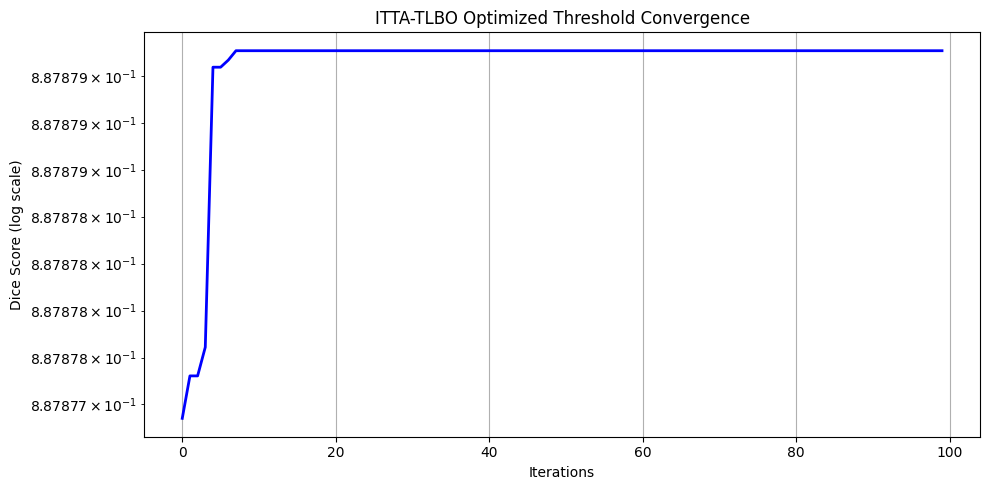

In [ ]:
# ===============================
# Parameters
# ===============================
player_no = 30
max_iter = 100
dim = 1  # Only one threshold value

lb = np.array([0.1])
ub = np.array([0.9])  # Threshold range between 0.1 and 0.9

# ===============================
# Initialization
# ===============================
Player_pos = np.random.rand(player_no, dim) * (ub - lb) + lb
Player_fitness = np.array([threshold_objective(Player_pos[i, :]) for i in range(player_no)])

best_idx = np.argmin(Player_fitness)
best_fit = Player_fitness[best_idx]
best_pos = Player_pos[best_idx, :]

nkeyplayer = max(3, round(0.1 * player_no))
keyplayer = np.full((nkeyplayer, dim + 1), np.inf)

convergence = np.zeros(max_iter)

# Coefficients for TTA
coef1 = 1.2
coef2 = 2.7
coef3 = 1.5
prob_lost = 0.2

# ===============================
# Main Loop
# ===============================
for iter in range(max_iter):
    sorted_idx = np.argsort(Player_fitness)
    Player_fitness = Player_fitness[sorted_idx]
    Player_pos = Player_pos[sorted_idx, :]
    top_cbest = np.hstack((Player_fitness[:nkeyplayer].reshape(-1, 1), Player_pos[:nkeyplayer]))

    for k in range(nkeyplayer):
        for m in range(nkeyplayer):
            if top_cbest[k, 0] < keyplayer[m, 0]:
                keyplayer[m, :] = top_cbest[k, :]
                break

    best_fit = keyplayer[0, 0]
    best_pos = keyplayer[0, 1:]
    convergence[iter] = best_fit

    if iter % 10 == 0:
        print(f"Iteration {iter} | Best Fitness: {best_fit:.6f}")

    Ball_pos = np.zeros((player_no, dim))
    for i in range(player_no):
        ip = player_no - 1 if i == 0 else i - 1
        a = np.random.rand(dim)
        if np.random.rand() > prob_lost:
            Ball_pos[i, :] = a * (Player_pos[ip, :] - Player_pos[i, :]) + Player_pos[i, :]
        else:
            aa = np.random.rand()
            direction = (coef1 + a) * (Player_pos[ip, :] - Player_pos[i, :])
            Ball_pos[i, :] = Player_pos[i, :] + direction if aa <= 0.5 else Player_pos[i, :] - direction

        Ball_pos[i, :] = np.clip(Ball_pos[i, :], lb, ub)

    for i in range(player_no):
        b = np.random.rand(dim)
        d = np.random.rand(dim)
        r = coef2 * (iter / max_iter)**2
        s = coef3 * (1 - iter / max_iter)**0.5
        kp = np.random.randint(0, nkeyplayer)

        new_pos = b * r * (Ball_pos[i, :] - Player_pos[i, :]) + \
                  d * s * (keyplayer[kp, 1:] - Player_pos[i, :]) + Player_pos[i, :]

        new_pos = np.clip(new_pos, lb, ub)
        new_fit = threshold_objective(new_pos)

        if new_fit < Player_fitness[i]:
            Player_pos[i, :] = new_pos
            Player_fitness[i] = new_fit

    # ----------- TLBO: Teacher Phase -----------
    teacher = Player_pos[0, :]
    TF = np.random.randint(1, 3)
    mean_pos = np.mean(Player_pos, axis=0)

    for i in range(player_no):
        new_pos = Player_pos[i, :] + np.random.rand(dim) * (teacher - TF * mean_pos)
        new_pos = np.clip(new_pos, lb, ub)
        new_fit = threshold_objective(new_pos)
        if new_fit < Player_fitness[i]:
            Player_pos[i, :] = new_pos
            Player_fitness[i] = new_fit

    # ----------- TLBO: Learner Phase -----------
    for i in range(player_no):
        j = np.random.randint(0, player_no)
        while j == i:
            j = np.random.randint(0, player_no)

        if Player_fitness[i] < Player_fitness[j]:
            new_pos = Player_pos[i, :] + np.random.rand(dim) * (Player_pos[i, :] - Player_pos[j, :])
        else:
            new_pos = Player_pos[i, :] + np.random.rand(dim) * (Player_pos[j, :] - Player_pos[i, :])

        new_pos = np.clip(new_pos, lb, ub)
        new_fit = threshold_objective(new_pos)
        if new_fit < Player_fitness[i]:
            Player_pos[i, :] = new_pos
            Player_fitness[i] = new_fit

# ===============================
# Results
# ===============================
print("\n=========================")
print(f"Best Fitness (Dice) = {-best_fit:.10f}")
print(f"Best Threshold = {best_pos[0]:.4f}")

# Plot
plt.figure(figsize=(10, 5))
plt.semilogy(-convergence, 'b', linewidth=2)
plt.xlabel('Iterations')
plt.ylabel('Dice Score (log scale)')
plt.title('ITTA-TLBO Optimized Threshold Convergence')
plt.grid(True)
plt.tight_layout()
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 274ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


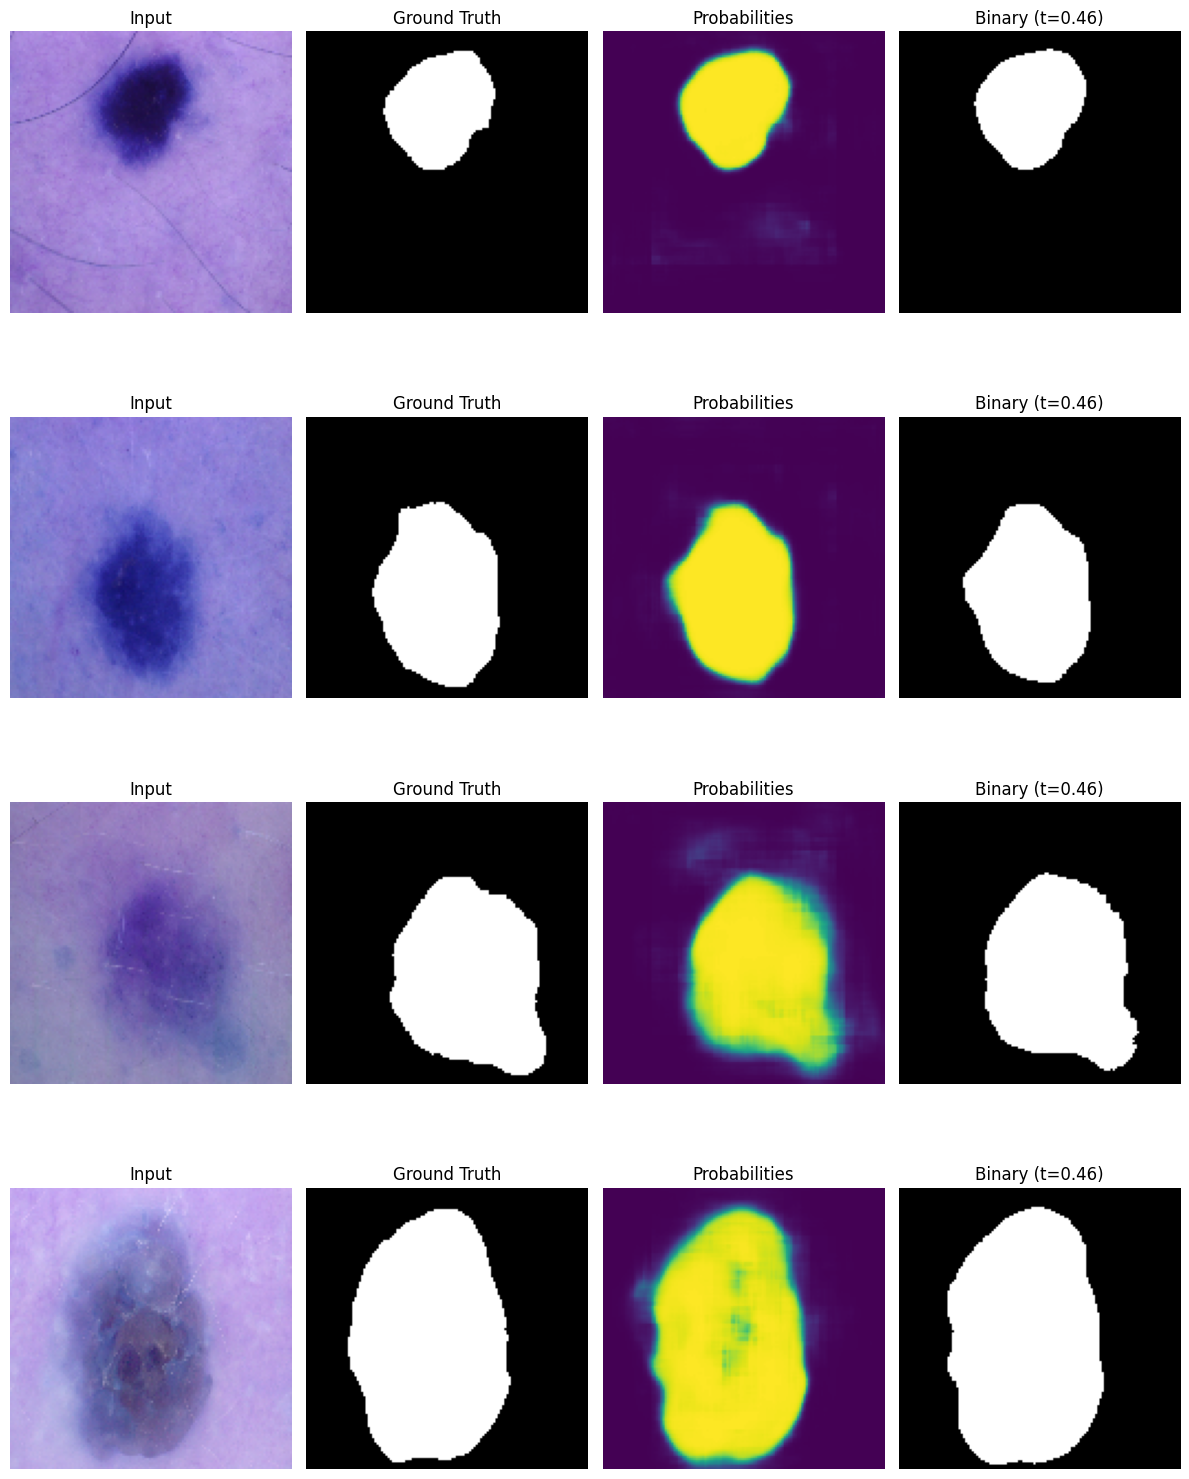

In [ ]:


# choose a few random indices from validation set
indices = [0, 5, 10, 15]

best_threshold = 0.4611  # from optimization

plt.figure(figsize=(12, len(indices) * 4))

for row, idx in enumerate(indices):
    # prediction probabilities
    pred_prob = model.predict(X_val[idx:idx+1])[0, :, :, 0]
    # apply threshold
    pred_mask = (pred_prob > best_threshold).astype(np.uint8)

    # input
    plt.subplot(len(indices), 4, row*4 + 1)
    plt.imshow(X_val[idx])
    plt.title("Input")
    plt.axis("off")

    # ground truth
    plt.subplot(len(indices), 4, row*4 + 2)
    plt.imshow(Y_val[idx].squeeze(), cmap="gray")
    plt.title("Ground Truth")
    plt.axis("off")

    # soft prediction
    plt.subplot(len(indices), 4, row*4 + 3)
    plt.imshow(pred_prob, cmap="viridis")
    plt.title("Probabilities")
    plt.axis("off")

    # thresholded mask
    plt.subplot(len(indices), 4, row*4 + 4)
    plt.imshow(pred_mask, cmap="gray")
    plt.title(f"Binary (t={best_threshold:.2f})")
    plt.axis("off")

plt.tight_layout()
plt.show()
